## 🛠️ Setup - Create Virtual Environment & Install Packages

Run the cell below **once** before anything else. It will:
1. Create a `.venv` folder at the root of this repo
2. Install all required libraries into it
3. Print the path so you can select it as your kernel in VS Code

> 💡 **After running:** Press `Ctrl+Shift+P` (or `Cmd+Shift+P` on Mac) → **Python: Select Interpreter** → choose the `.venv` option that appears, then **restart the kernel** and continue.

In [ ]:
import subprocess, sys, os
from pathlib import Path

# ── Locate repo root (two levels up from this notebook) ──────────────────────
REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd().parent
VENV_DIR  = REPO_ROOT / ".venv"

PACKAGES = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "plotly", "scipy", "requests", "duckdb", "ipykernel", "nbformat", "folium",
]

# ── Create the virtual environment if it doesn't already exist ───────────────
if not VENV_DIR.exists():
    print(f"Creating virtual environment at: {VENV_DIR} ...")
    subprocess.check_call([sys.executable, "-m", "venv", str(VENV_DIR)])
    print("✅ Virtual environment created.")
else:
    print(f"✅ Virtual environment already exists at: {VENV_DIR}")

# ── Resolve the pip executable inside the venv ───────────────────────────────
pip_exec = (
    VENV_DIR / "bin" / "pip"          # macOS / Linux
    if os.name != "nt"
    else VENV_DIR / "Scripts" / "pip" # Windows
)

# ── Install / upgrade packages ───────────────────────────────────────────────
print("\nInstalling packages (this may take a minute the first time) ...")
subprocess.check_call([str(pip_exec), "install", "--upgrade", "pip", "-q"])
subprocess.check_call([str(pip_exec), "install", *PACKAGES, "-q"])
print("✅ All packages installed.\n")

# ── Register the venv as a Jupyter kernel so VS Code can select it ───────────
python_exec = (
    VENV_DIR / "bin" / "python"
    if os.name != "nt"
    else VENV_DIR / "Scripts" / "python"
)
subprocess.check_call([
    str(python_exec), "-m", "ipykernel", "install",
    "--user", "--name", "sky-copilot-workshop",
    "--display-name", "Python (.venv - sky-copilot-workshop)",
])
print("✅ Kernel registered.\n")
print("=" * 60)
print(f"  Venv path  : {VENV_DIR}")
print(f"  Python     : {python_exec}")
print("=" * 60)
print("\n👉 Next step: Cmd+Shift+P → 'Python: Select Interpreter'")
print("   Choose:  Python (.venv - sky-copilot-workshop)")
print("   Then:    Restart the kernel and run the notebook from the top.")


# 🏠 Airbnb Data Analysis - GitHub Copilot Workshop

Welcome! In this workshop you'll explore real Airbnb listing data for **New York, London, Paris, Amsterdam, and Barcelona** - and learn how **GitHub Copilot** can help you do more advanced analytical work without needing deep programming skills.

---

## What you'll learn
| Module | Theme |
|---|---|
| **1 - Understand the data** | Load a dataset and explore its structure with Copilot's help |
| **2 - Clean & prepare** | Spot and fix data quality issues faster using Copilot |
| **3 - Explore & visualise** | Generate charts from plain-English descriptions |
| **4 - SQL with DuckDB** | Run SQL queries on the data - no database server needed |
| **5 - Geospatial heat map** | Map listing density and price tiers across each city |
| **6 - Reusable functions** | Turn one-off scripts into functions you can use again |
| **7 - Explain & document** | Use Copilot to translate analysis into plain language |

---

## How to use Copilot in VS Code

| Action | How |
|---|---|
| Open Copilot Chat | `Ctrl+Alt+I` (Windows) / `Cmd+Option+I` (Mac) |
| Explain selected code | Select code → right-click → **Copilot: Explain** |
| Inline suggestion | Start typing a comment or code - Copilot autocompletes |
| Fix an error | Paste the error message into Copilot Chat |

Throughout this notebook you'll see **🤖 Copilot Prompts** - copy these into Copilot Chat to see how it responds.


In [ ]:
# Install required packages
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "plotly", "scipy", "requests", "duckdb", "nbformat", "folium",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap
import duckdb
import warnings, io, requests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Libraries ready.")


---
## Module 1 - Understanding Your Data 🔍

The first step in any analysis is understanding what you're working with: how many rows, what columns, what data types, and where the gaps are. Copilot can help you do this faster by explaining what each column means and suggesting what to look at first.

**Finance & analytics context:** This mirrors connecting to a new data source - you need to understand the structure before you trust the numbers.

---
### 🤖 Copilot Prompts - try these as you run the cells below

> 💬 *"We have an Airbnb listings dataset with columns: id, name, host_id, neighbourhood, room_type, price, minimum_nights, number_of_reviews, availability_365, city. Which columns would be most useful for understanding what drives listing prices?"*

> 💬 *"The price column is missing for most rows in our dataset. What are the likely reasons for this, and how would you investigate it?"*

> 💬 *"Explain what the `availability_365` column likely represents in the context of an Airbnb listing, and what a very low or very high value would mean for a property owner."*

💡 **Tip:** You can select any code cell, right-click, and choose **Copilot: Explain** to get an inline explanation - useful when you inherit code you didn't write.

In [ ]:

# Load data from Inside Airbnb - sample 2,000 rows per city
# This keeps the total dataset small so the workshop runs quickly.
#
# ⚠️  Paris note: the /visualisations/listings.csv for French cities does not
#     include price data (a known Inside Airbnb limitation for French extracts).
#     Paris therefore uses the full /data/listings.csv.gz, which does include price.

SAMPLE_PER_CITY = 2_000

# Each entry: (url, is_gzip)
CITIES = {
    "New York":   ("https://data.insideairbnb.com/united-states/ny/new-york-city/2026-02-13/visualisations/listings.csv", False),
    "London":     ("https://data.insideairbnb.com/united-kingdom/england/london/2025-09-14/visualisations/listings.csv", False),
    "Paris":      ("https://data.insideairbnb.com/france/ile-de-france/paris/2025-09-12/data/listings.csv.gz", True),
    "Amsterdam":  ("https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2025-09-11/visualisations/listings.csv", False),
    "Barcelona":  ("https://data.insideairbnb.com/spain/catalonia/barcelona/2025-12-14/visualisations/listings.csv", False),
}

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/123.0 Safari/537.36"
    ),
    "Referer": "https://insideairbnb.com/",
}

# Columns we need - the full listings.csv has 70+ columns so we slim it down
KEEP_COLS = [
    "id", "name", "host_id", "host_name",
    "neighbourhood_cleansed", "neighbourhood",
    "latitude", "longitude",
    "room_type", "price",
    "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count",
    "availability_365",
]

frames = []
for city, (url, is_gzip) in CITIES.items():
    print(f"  Downloading {city} ...", end=" ", flush=True)
    try:
        r = requests.get(url, timeout=120, headers=HEADERS)
        r.raise_for_status()
        compression = "gzip" if is_gzip else None
        df_tmp = pd.read_csv(io.BytesIO(r.content), compression=compression, low_memory=False)
        df_tmp["city"] = city
        # Keep only the columns we need (ignore missing ones gracefully)
        cols = [c for c in KEEP_COLS if c in df_tmp.columns] + ["city"]
        df_tmp = df_tmp[cols]
        # Normalise neighbourhood column name
        if "neighbourhood_cleansed" in df_tmp.columns and "neighbourhood" not in df_tmp.columns:
            df_tmp = df_tmp.rename(columns={"neighbourhood_cleansed": "neighbourhood"})
        df_tmp = df_tmp.sample(min(SAMPLE_PER_CITY, len(df_tmp)), random_state=42)
        frames.append(df_tmp)
        print(f"✅  {len(df_tmp):,} rows")
    except Exception as e:
        print(f"⚠️  Failed: {e}")

df = pd.concat(frames, ignore_index=True)
print(f"\n📊 Workshop dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")


In [ ]:
# First look: shape, column names, sample rows
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nListings per city:")
print(df["city"].value_counts().to_string())

df.head(5)

In [ ]:
# Data quality: missing values and data types
missing = (df.isnull().sum() / len(df) * 100).rename("missing_%").round(1)
dtypes  = df.dtypes.rename("dtype")
overview = pd.concat([dtypes, missing], axis=1).sort_values("missing_%", ascending=False)
print(overview.to_string())

In [ ]:
# Numeric summary statistics
df.describe().T

---
## Module 2 - Cleaning & Preparing Data 🧹

Real-world data is always messy. Here we'll fix data types, handle missing values, and create new columns that make the analysis more useful. Copilot is particularly good at suggesting the *right* way to handle data quality issues.

**Finance & analytics context:** This is the data validation step - the equivalent of checking your source data before building a report or model.

---
### 🤖 Copilot Prompts

> 💬 *"The price column in my DataFrame is missing for most cities. Write Python code to show exactly how many rows have a valid price per city, and what percentage that is of each city's total."*

> 💬 *"Add a new column called `price_tier` that categorises listings as Budget, Mid-range, or Luxury using the 33rd and 66th price percentiles within each city. Return 'Unknown' if price is missing."*

> 💬 *"I have a `minimum_nights` column with some extreme values over 365. Write code to classify listings as Short-term, Weekly, or Long-term based on this column."*

> 💬 *"Write code to check for and remove duplicate listing IDs, then print how many duplicates were found."*

💡 **Tip:** When prompting Copilot, mention the column names and data types - the more context you give, the better the result.

In [ ]:
# Clean price column - strip currency symbols if stored as text
if df["price"].dtype == object:
    df["price"] = (
        df["price"]
        .str.replace(r"[$,£€]", "", regex=True)
        .str.strip()
        .replace("", np.nan)
        .astype(float)
    )

# Flag rows with usable price data
df["has_price"] = df["price"].notna() & (df["price"] > 0)

# Cap outliers at the 99th percentile per city for cleaner charts
p99 = df.groupby("city")["price"].transform(lambda x: x.quantile(0.99))
df["price_capped"] = df["price"].clip(upper=p99)

# Ensure numeric types
for col in ["number_of_reviews", "reviews_per_month",
            "calculated_host_listings_count", "availability_365", "minimum_nights"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Classify rental duration based on minimum_nights
def classify_rental(min_nights):
    if pd.isna(min_nights):    return "Unknown"
    if min_nights >= 30:       return "Long-term (30+ nights)"
    if min_nights >= 7:        return "Weekly+"
    return "Short-term"

df["rental_type"] = df["minimum_nights"].apply(classify_rental)

print("Price availability by city:")
price_avail = df.groupby("city")["has_price"].mean().mul(100).round(1)
for city, pct in price_avail.items():
    bar = "█" * int(pct / 5)
    print(f"  {city:<12} {bar:<20} {pct}%")

In [ ]:
df.head()

In [ ]:
# Add price tier column - grouped by city so tiers are relative to local market
# Uses transform() to avoid pandas 2.x groupby/apply column-dropping issues

def assign_price_tier(price: float, p33: float, p66: float) -> str:
    """Returns Budget / Mid-range / Luxury based on where price falls in the city distribution."""
    if pd.isna(price):  return "Unknown"
    if price <= p33:    return "Budget"
    if price <= p66:    return "Mid-range"
    return "Luxury"

price_tiers = []
for city, group in df.groupby("city"):
    prices = group["price"].dropna()
    if len(prices) < 10:
        tiers = pd.Series("Unknown", index=group.index)
    else:
        p33 = prices.quantile(0.33)
        p66 = prices.quantile(0.66)
        tiers = group["price"].apply(lambda p: assign_price_tier(p, p33, p66))
    price_tiers.append(tiers)

df["price_tier"] = pd.concat(price_tiers).reindex(df.index)

print("Price tier distribution (cities with price data):")
print(df[df["has_price"]]["price_tier"].value_counts().to_string())
print(f"\n✅ Columns intact - 'city' present: {'city' in df.columns}")


In [ ]:
df.head()

---
## Module 3 - Explore & Visualise 📊

Now for the interesting part. We'll create charts to understand patterns in the data. Copilot is excellent at generating chart code from plain-English descriptions - you describe what you want to see, and it writes the code.

**Finance & analytics context:** Think of these as the charts you'd put in a dashboard or board pack. The goal is to tell a clear story about the data.

---
### 🤖 Copilot Prompts

> 💬 *"Create a horizontal bar chart showing the top 10 neighbourhoods across all cities by number of listings. Colour the bars by city and add data labels."*

> 💬 *"Plot the distribution of `number_of_reviews` for each city on the same chart as a KDE (kernel density) plot. Add a legend, title, and axis labels."*

> 💬 *"The chart I just created is hard to read. Make the axis labels bigger, add gridlines, and use a colour-blind-friendly palette."*

> 💬 *"Create an interactive Plotly bar chart showing the percentage of each room type per city, stacked to 100%. Add a hover tooltip showing the exact count."*

💡 **Tip:** After Copilot generates a chart, try asking it to improve it iteratively: *"Make this more readable for a non-technical audience"* or *"Change the colour palette"*.

In [ ]:
# Overview: listings per city and room type breakdown
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

city_counts = df["city"].value_counts().reset_index()
city_counts.columns = ["City", "Listings"]
# Fix: seaborn v0.13+ requires hue when using palette on a categorical axis
sns.barplot(data=city_counts, x="City", y="Listings",
            hue="City", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Listings per City (sample of 2,000)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

room_counts = df["room_type"].value_counts().reset_index()
room_counts.columns = ["Room Type", "Count"]
sns.barplot(data=room_counts, x="Room Type", y="Count",
            hue="Room Type", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Room Type Distribution - All Cities", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()


In [ ]:
# Price analysis - robust even if Module 2 cleaning cell wasn't run yet

# Guard: ensure df exists and has the required columns
if "df" not in dir() or not hasattr(df, "columns") or "city" not in df.columns:
    print("⚠️  df is not loaded yet. Please run the data-loading cell (Module 1) first, then re-run this cell.")
else:
    df_price = df.copy()

    # Derive has_price if missing
    if "has_price" not in df_price.columns:
        if "price" in df_price.columns:
            if df_price["price"].dtype == object:
                df_price["price"] = (
                    df_price["price"]
                    .str.replace(r"[$,£€]", "", regex=True)
                    .str.strip()
                    .replace("", np.nan)
                )
            df_price["price"] = pd.to_numeric(df_price["price"], errors="coerce")
            df_price["has_price"] = df_price["price"].notna() & (df_price["price"] > 0)
        else:
            df_price["has_price"] = False

    # Derive price_capped if missing
    if "price_capped" not in df_price.columns:
        if df_price["has_price"].any():
            p99 = df_price.groupby("city")["price"].transform(lambda x: x.quantile(0.99))
            df_price["price_capped"] = df_price["price"].clip(upper=p99)
        else:
            df_price["price_capped"] = np.nan

    df_price = df_price[df_price["has_price"]].copy()

    if not df_price.empty:
        cities = sorted(df_price["city"].unique())

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ── Left: price by city (pure matplotlib - no seaborn version issues) ──
        city_data = [df_price.loc[df_price["city"] == c, "price_capped"].dropna().values
                     for c in cities]
        bp1 = axes[0].boxplot(city_data, patch_artist=True, labels=cities,
                              medianprops=dict(color="black", linewidth=1.5))
        pastel = plt.cm.Pastel1.colors
        for patch, color in zip(bp1["boxes"], pastel[:len(cities)]):
            patch.set_facecolor(color)
        axes[0].set_title("Nightly Price by City (capped at 99th percentile)",
                          fontsize=12, fontweight="bold")
        axes[0].set_xlabel("")
        axes[0].set_ylabel("Nightly Price (local currency)")
        axes[0].tick_params(axis="x", rotation=20)

        # ── Right: price by room type & city ────────────────────────────────
        sns.boxplot(data=df_price, x="room_type", y="price_capped",
                    hue="city", ax=axes[1])
        axes[1].set_title("Price by Room Type & City", fontsize=12, fontweight="bold")
        axes[1].set_xlabel("")
        axes[1].set_ylabel("Nightly Price")
        axes[1].legend(title="City", bbox_to_anchor=(1.01, 1), loc="upper left")

        plt.tight_layout()
        plt.show()

        print("Median nightly price by city:")
        print(df_price.groupby("city")["price"].median().sort_values(ascending=False).to_string())
    else:
        print("No price data available in this sample.")


In [ ]:
# Reviews and availability patterns across cities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

med_reviews = df.groupby("city")["number_of_reviews"].median().sort_values(ascending=False)
med_reviews.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Median Number of Reviews by City", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Median Reviews")
axes[0].tick_params(axis="x", rotation=30)

for city in df["city"].unique():
    sub = df[df["city"] == city]["availability_365"].dropna()
    # Guard: KDE needs at least 2 non-identical values
    if len(sub) >= 2 and sub.std() > 0:
        sub.plot.kde(ax=axes[1], label=city)
axes[1].set_title("Availability (Days/Year) Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Days Available per Year")
axes[1].legend()
axes[1].set_xlim(0, 365)

plt.tight_layout()
plt.show()


In [ ]:
# Interactive chart: room type share per city
room_share = (
    df.groupby(["city", "room_type"])
    .size()
    .reset_index(name="count")
)
room_share["pct"] = room_share.groupby("city")["count"].transform(
    lambda x: x / x.sum() * 100
).round(1)

fig = px.bar(
    room_share, x="city", y="pct", color="room_type",
    barmode="stack",
    title="Room Type Share per City (%)",
    labels={"pct": "Share (%)", "city": "", "room_type": "Room Type"},
    template="plotly_white",
    height=450,
    text="pct",
)
fig.update_traces(texttemplate="%{text:.0f}%", textposition="inside")
fig.show()

---
## Module 4 - SQL Queries with DuckDB 🗄️

**DuckDB** lets you run SQL queries directly on a pandas DataFrame - no database server, no connection string, no setup. If you're already writing SQL in a BI tool or data warehouse, you can use those same skills here.

DuckDB supports standard SQL including `GROUP BY`, `WHERE`, `JOIN`, window functions (`RANK`, `ROW_NUMBER`, `OVER`), and CTEs (`WITH` clauses).

**Finance & analytics context:** Think of this as writing queries against a spreadsheet or a flat file - without needing Excel or a cloud database.

---
### 🤖 Copilot Prompts

> 💬 *"Write a DuckDB SQL query to find the top 5 neighbourhoods per city by number of listings, using a window function with RANK()."*

> 💬 *"Translate this pandas code into a DuckDB SQL query: `df.groupby(['city','room_type'])['number_of_reviews'].mean().round(1)`"*

> 💬 *"Write a SQL query using a CTE that first calculates the average availability per city, then finds all listings that are available more than 1.5× their city's average."*

> 💬 *"Write a SQL query to classify listings as Short-term, Weekly, or Long-term based on minimum_nights, and show the count and average reviews for each category per city."*

💡 **Tip:** You can paste a SQL result table back into Copilot Chat and ask *"What does this output tell us about the data?"* - great for getting a plain-English interpretation.

In [ ]:
# DuckDB queries the `df` DataFrame directly - no loading required.
# Just reference the variable name as if it were a table.

# Quick test: listing counts by city
duckdb.query("""
    SELECT city, COUNT(*) AS listings
    FROM df
    GROUP BY city
    ORDER BY listings DESC
""").df()

In [ ]:
# Room type breakdown per city - count and percentage share
duckdb.query("""
    SELECT
        city,
        room_type,
        COUNT(*) AS listings,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY city),
        1) AS pct_of_city
    FROM df
    GROUP BY city, room_type
    ORDER BY city, listings DESC
""").df()

In [ ]:
# Top neighbourhoods by review activity - a proxy for booking demand
duckdb.query("""
    SELECT
        city,
        neighbourhood,
        COUNT(*)                          AS listings,
        ROUND(AVG(number_of_reviews), 1)  AS avg_reviews,
        ROUND(AVG(availability_365), 0)   AS avg_availability_days
    FROM df
    WHERE neighbourhood IS NOT NULL
    GROUP BY city, neighbourhood
    HAVING COUNT(*) >= 5
    ORDER BY avg_reviews DESC
    LIMIT 15
""").df()

In [ ]:
# Short-term vs long-term rental mix by city
duckdb.query("""
    SELECT
        city,
        CASE
            WHEN minimum_nights >= 30 THEN 'Long-term (30+ nights)'
            WHEN minimum_nights >= 7  THEN 'Weekly+'
            ELSE 'Short-term'
        END AS rental_category,
        COUNT(*)                         AS listings,
        ROUND(AVG(number_of_reviews), 1) AS avg_reviews,
        ROUND(AVG(availability_365), 0)  AS avg_availability
    FROM df
    WHERE minimum_nights IS NOT NULL
    GROUP BY city, rental_category
    ORDER BY city, listings DESC
""").df()

### ✏️ SQL Challenge - Your Turn

Use Copilot to help you write these queries in the cell below.

**Challenge 1 (Easy):** Find the average `availability_365` for each room type across all cities.

**Challenge 2 (Medium):** Find the top 3 neighbourhoods per city by number of listings.  
*(Hint: ask Copilot about `RANK() OVER (PARTITION BY city ORDER BY ...)`)* 

**Challenge 3 (Hard):** Use a CTE to find listings with **above-average reviews AND above-average availability** for their city. How many are there per city?

In [ ]:
# Write your SQL query here.
# Use: duckdb.query("""  YOUR SQL  """).df()

# Tip: ask Copilot - "Write a DuckDB SQL query to..."


---
## Module 5 - Geospatial Heat Map 🗺️

Airbnb listings carry precise **latitude** and **longitude** coordinates, which lets us plot *where* supply concentrates across each city. Layering price and availability data on top reveals neighbourhood-level patterns that tables and bar charts cannot show.

**Finance & analytics context:** Location intelligence is a core input to real-estate and hospitality pricing models. A heat map instantly highlights which districts command premium prices - and where competition is densest.

> 💡 **Copilot tip:** Describe the chart in plain English - *"show me a folium heat map of listing density for London"* - and Copilot will write the `folium` code for you.

In [ ]:

import folium
from folium.plugins import HeatMap
from IPython.display import display, HTML
from pathlib import Path

# City centre coordinates for auto-centering
CITY_CENTRES = {
    "New York":   [40.7128, -74.0060],
    "London":     [51.5074,  -0.1278],
    "Paris":      [48.8566,   2.3522],
    "Amsterdam":  [52.3676,   4.9041],
    "Barcelona":  [41.3851,   2.1734],
}

# ── Choose a city to display ──────────────────────────────────────────────────
# Cities with full price data in this extract:  London, New York, Amsterdam, Barcelona
# Paris uses the full data extract so also has price data now.
# Change this to any city in the list above to explore a different map.
city_choice = "London"

city_df = df[df["city"] == city_choice].dropna(subset=["latitude", "longitude"])

centre = CITY_CENTRES[city_choice]
m = folium.Map(location=centre, zoom_start=12, tiles="OpenStreetMap")

heat_data = city_df[["latitude", "longitude"]].values.tolist()
HeatMap(heat_data, radius=10, blur=15, min_opacity=0.4).add_to(m)

title_html = f"""
    <div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
                background:white;padding:6px 14px;border-radius:6px;
                font-size:15px;font-weight:bold;z-index:9999;box-shadow:2px 2px 6px rgba(0,0,0,.3)">
        {city_choice} - Listing Density Heat Map
    </div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# Save to workspace folder - open in browser if inline doesn't render
out_path = Path.cwd().parent / "samples" / f"map_heatmap_{city_choice.replace(' ', '_')}.html"
m.save(str(out_path))
print(f"✅ Map saved → open in browser: {out_path}")
print("💡 To render inline: Cmd+Shift+P → 'Jupyter: Trust Current Notebook' → re-run cell")

# Also attempt inline render
display(HTML(f'<div style="height:520px">{m._repr_html_()}</div>'))


✅ Map saved → open in browser: /Users/kpl415/Documents/WORKSHOPS/GITHUB-COPILOT/sky-copilot-workshop/samples/map_heatmap_London.html
💡 To render inline: Cmd+Shift+P → 'Jupyter: Trust Current Notebook' → re-run cell


In [ ]:

# Colour each listing dot by its price tier
TIER_COLOURS = {
    "Budget":    "#2ecc71",
    "Mid-range": "#f39c12",
    "Luxury":    "#e74c3c",
    "Unknown":   "#95a5a6",
}

# Room-type fallback colours (used when no price data is available)
ROOM_COLOURS = {
    "Entire home/apt": "#3498db",
    "Private room":    "#9b59b6",
    "Shared room":     "#e67e22",
    "Hotel room":      "#1abc9c",
}

city_df_priced = df[
    (df["city"] == city_choice) & df["has_price"]
].dropna(subset=["latitude", "longitude"])

city_df_all = df[df["city"] == city_choice].dropna(subset=["latitude", "longitude"])

use_price_tiers = len(city_df_priced) > 0

print(f"City: {city_choice}")
print(f"  Total listings with coordinates : {len(city_df_all):,}")
print(f"  Listings with valid price data  : {len(city_df_priced):,}")

if not use_price_tiers:
    print(f"\n⚠️  No price data available for {city_choice} in this extract.")
    print("   Falling back to room-type colouring.\n")

m2 = folium.Map(location=centre, zoom_start=12, tiles="OpenStreetMap")

plot_df = city_df_priced if use_price_tiers else city_df_all

for _, row in plot_df.iterrows():
    if use_price_tiers:
        colour = TIER_COLOURS.get(row["price_tier"], "#95a5a6")
        popup_html = (
            f"<b>{row['name']}</b><br>"
            f"Tier: {row['price_tier']}<br>"
            f"Price: {row['price_capped']:.0f}<br>"
            f"Room: {row['room_type']}<br>"
            f"Neighbourhood: {row['neighbourhood']}"
        )
    else:
        colour = ROOM_COLOURS.get(row["room_type"], "#95a5a6")
        popup_html = (
            f"<b>{row['name']}</b><br>"
            f"Room: {row['room_type']}<br>"
            f"Neighbourhood: {row['neighbourhood']}<br>"
            f"Min nights: {row['minimum_nights']}"
        )
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,
        color=colour,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250),
    ).add_to(m2)

# Build legend based on what we're showing
if use_price_tiers:
    legend_items = "".join(
        f"<span style='color:{c}'>&#9679;</span> {label}<br>"
        for label, c in TIER_COLOURS.items()
    )
    legend_title = "Price tier"
else:
    legend_items = "".join(
        f"<span style='color:{c}'>&#9679;</span> {label}<br>"
        for label, c in ROOM_COLOURS.items()
    )
    legend_title = "Room type"

legend_html = f"""
    <div style="position:fixed;bottom:30px;left:20px;background:white;
                padding:10px 16px;border-radius:8px;z-index:9999;
                font-size:13px;box-shadow:2px 2px 6px rgba(0,0,0,.3)">
        <b>{legend_title}</b><br>
        {legend_items}
    </div>
"""
m2.get_root().html.add_child(folium.Element(legend_html))

map_subtitle = "Listings by Price Tier" if use_price_tiers else "Listings by Room Type (no price data)"
title_html2 = f"""
    <div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
                background:white;padding:6px 14px;border-radius:6px;
                font-size:15px;font-weight:bold;z-index:9999;box-shadow:2px 2px 6px rgba(0,0,0,.3)">
        {city_choice} - {map_subtitle}
    </div>
"""
m2.get_root().html.add_child(folium.Element(title_html2))

# Save to workspace folder - open in browser if inline doesn't render
out_path2 = Path.cwd().parent / "samples" / f"map_price_tier_{city_choice.replace(' ', '_')}.html"
m2.save(str(out_path2))
print(f"✅ Map saved → open in browser: {out_path2}")
print("💡 To render inline: Cmd+Shift+P → 'Jupyter: Trust Current Notebook' → re-run cell")

# Also attempt inline render
display(HTML(f'<div style="height:520px">{m2._repr_html_()}</div>'))


City: London
  Total listings with coordinates : 2,000
  Listings with valid price data  : 1,273
✅ Map saved → open in browser: /Users/kpl415/Documents/WORKSHOPS/GITHUB-COPILOT/sky-copilot-workshop/samples/map_price_tier_London.html
💡 To render inline: Cmd+Shift+P → 'Jupyter: Trust Current Notebook' → re-run cell
✅ Map saved → open in browser: /Users/kpl415/Documents/WORKSHOPS/GITHUB-COPILOT/sky-copilot-workshop/samples/map_price_tier_London.html
💡 To render inline: Cmd+Shift+P → 'Jupyter: Trust Current Notebook' → re-run cell


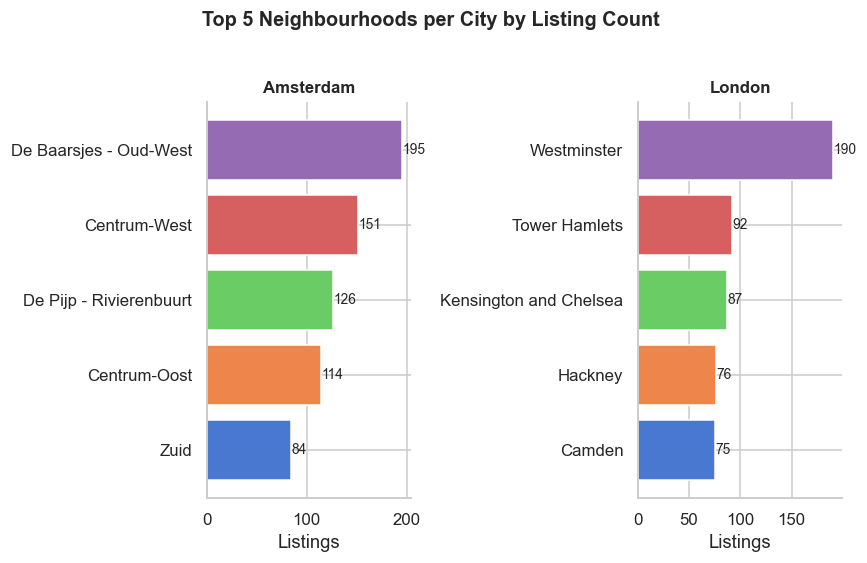

In [ ]:
import duckdb

# Neighbourhood-level statistics - top 5 per city by listing count
# Minimum 10 listings per neighbourhood to filter out statistical noise
neighbourhood_stats = duckdb.query("""
    SELECT
        city,
        neighbourhood,
        COUNT(*)                                       AS listings,
        ROUND(MEDIAN(price_capped), 0)                 AS median_price,
        ROUND(AVG(availability_365), 1)                AS avg_availability_days,
        ROUND(AVG(number_of_reviews), 1)               AS avg_reviews,
        ROUND(AVG(calculated_host_listings_count), 1)  AS avg_host_listings
    FROM df
    WHERE has_price
      AND neighbourhood IS NOT NULL
    GROUP BY city, neighbourhood
    HAVING COUNT(*) >= 10
    ORDER BY city, listings DESC
""").df()

# Top 5 neighbourhoods per city - use rank() to avoid pandas groupby column-drop issues
neighbourhood_stats["rank"] = (
    neighbourhood_stats
    .groupby("city")["listings"]
    .rank(method="first", ascending=False)
)
top5 = neighbourhood_stats[neighbourhood_stats["rank"] <= 5].reset_index(drop=True)

# Plot: faceted horizontal bar charts - one panel per city
cities = top5["city"].unique()
n_cities = len(cities)

fig, axes = plt.subplots(1, n_cities, figsize=(4 * n_cities, 5), sharey=False)
if n_cities == 1:
    axes = [axes]

palette = sns.color_palette("muted", 5)

for ax, city in zip(axes, cities):
    data = top5[top5["city"] == city].sort_values("listings")
    bars = ax.barh(data["neighbourhood"], data["listings"], color=palette)
    ax.set_title(city, fontsize=11, fontweight="bold")
    ax.set_xlabel("Listings")
    ax.set_ylabel("")
    # Add value labels at end of each bar
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{int(width)}", va="center", ha="left", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 5 Neighbourhoods per City by Listing Count", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## How to read the results:

A more insightful heatmap here would be a neighbourhood × metric pivot - showing median price, availability, and review rate for each of the top 5 London neighbourhoods side by side. This tells a richer story than a simple correlation coefficient.

🟢 Green = that neighbourhood performs above average on that metric relative to the other four

🔴 Red = below average
The bar chart on the right gives an absolute price anchor so you're not just reading relative colours

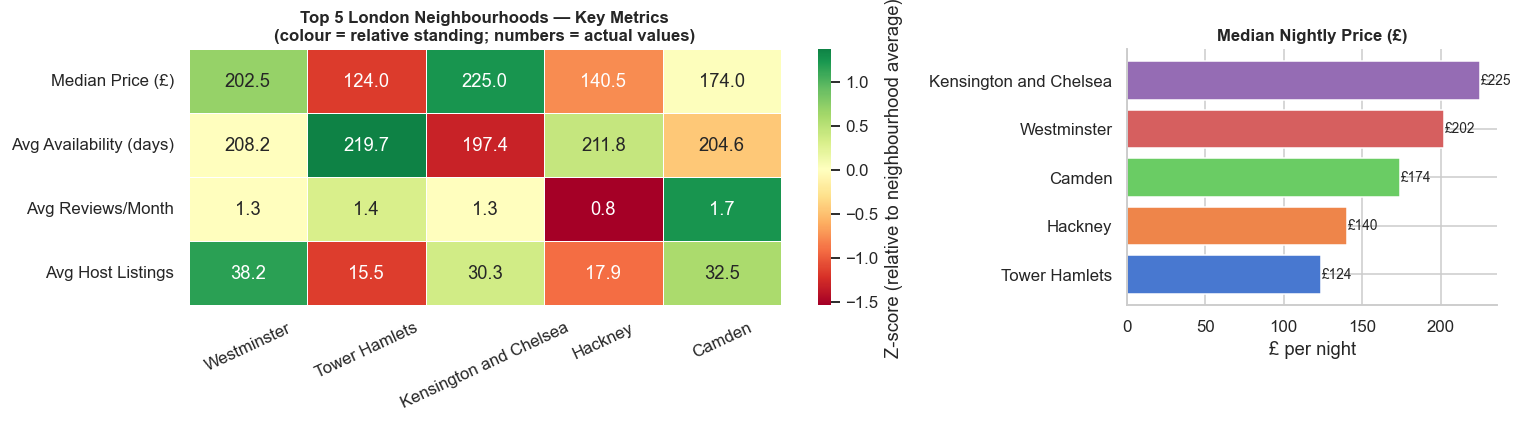

In [ ]:
# Neighbourhood profile heatmap for the top 5 London neighbourhoods
# Shows median price, availability, reviews per month, and host listing count
# - normalised (z-score) so all metrics share the same colour scale

london_df = df[(df["city"] == "London") & df["has_price"]].copy()

if not london_df.empty:
    top_neighbourhoods = (
        london_df["neighbourhood"]
        .value_counts()
        .nlargest(5)
        .index.tolist()
    )

    metrics = {
        "Median Price (£)":        ("price_capped",                    "median"),
        "Avg Availability (days)": ("availability_365",                 "mean"),
        "Avg Reviews/Month":       ("reviews_per_month",               "mean"),
        "Avg Host Listings":       ("calculated_host_listings_count",  "mean"),
    }

    rows = {}
    subset = london_df[london_df["neighbourhood"].isin(top_neighbourhoods)]
    for label, (col, agg) in metrics.items():
        if col in subset.columns:
            rows[label] = (
                subset.groupby("neighbourhood")[col]
                .agg(agg)
                .reindex(top_neighbourhoods)
                .round(1)
            )

    profile = pd.DataFrame(rows).T   # metrics as rows, neighbourhoods as columns

    # Z-score normalise across neighbourhoods so metrics are comparable
    profile_norm = profile.apply(lambda row: (row - row.mean()) / row.std(), axis=1)

    fig, axes = plt.subplots(
        1, 2, figsize=(14, 4),
        gridspec_kw={"width_ratios": [2, 1]}
    )

    # Left: normalised heatmap (pattern / relative standing)
    sns.heatmap(
        profile_norm,
        ax=axes[0],
        annot=profile.values,         # show raw values in each cell
        fmt=".1f",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Z-score (relative to neighbourhood average)"},
    )
    axes[0].set_title(
        "Top 5 London Neighbourhoods - Key Metrics\n(colour = relative standing; numbers = actual values)",
        fontsize=11, fontweight="bold"
    )
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    axes[0].tick_params(axis="x", rotation=25)

    # Right: bar chart of median price for quick comparison
    price_row = profile.loc["Median Price (£)"].sort_values(ascending=True)
    axes[1].barh(price_row.index, price_row.values, color=sns.color_palette("muted", len(price_row)))
    axes[1].set_title("Median Nightly Price (£)", fontsize=11, fontweight="bold")
    axes[1].set_xlabel("£ per night")
    for i, v in enumerate(price_row.values):
        axes[1].text(v + 0.5, i, f"£{v:.0f}", va="center", fontsize=9)
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No price data available for London in this extract.")


---
## Module 6 - Writing Reusable Functions 🔧

One of Copilot's most valuable skills: turning one-off analysis scripts into clean, reusable functions. You describe what the function should do - Copilot writes it.

**Finance & analytics context:** A reusable function is like a well-built Excel formula or a stored procedure: you define the logic once and apply it to any input. This is how you go from ad hoc analysis to a repeatable reporting process.

---
### 🤖 Copilot Prompts

> 💬 *"Turn the neighbourhood bar chart above into a function called `plot_top_neighbourhoods(df, city, n=10)`. It should accept a DataFrame, city name, and optional row count, and display a horizontal bar chart."*

> 💬 *"Write a function called `city_report(df, city)` that prints a formatted summary including: total listings, most common room type, median availability, median reviews, and top 3 neighbourhoods by listing count."*

> 💬 *"Add type hints and a docstring to this function, written for a finance analyst who is not a Python expert."*

> 💬 *"Write a function that exports a summary table to Excel, with one sheet per city. Use the openpyxl library."*

💡 **Tip:** After generating a function, ask Copilot: *"What edge cases should I add error handling for?"* - a great way to make code more robust without having to think of every scenario yourself.

In [ ]:
def city_summary(df: pd.DataFrame, city: str) -> dict:
    """
    Returns key metrics for a given city in the Airbnb dataset.

    Parameters
    ----------
    df   : The full listings DataFrame (must have a 'city' column).
    city : City name - must match a value in df['city'].

    Returns
    -------
    Dictionary with: total_listings, top_room_type, median_availability,
    median_reviews, top_neighbourhood.
    """
    subset = df[df["city"] == city]
    if subset.empty:
        return {"error": f"No data found for city: {city}"}

    nbh_col  = "neighbourhood_cleansed" if "neighbourhood_cleansed" in df.columns else "neighbourhood"
    top_room = subset["room_type"].value_counts().idxmax()
    top_nbh  = subset[nbh_col].value_counts().idxmax() if nbh_col in subset.columns else "N/A"

    return {
        "city":                city,
        "total_listings":      len(subset),
        "top_room_type":       top_room,
        "median_availability": round(subset["availability_365"].median(), 0),
        "median_reviews":      round(subset["number_of_reviews"].median(), 1),
        "top_neighbourhood":   top_nbh,
    }


# Run for every city
for city in sorted(df["city"].unique()):
    s = city_summary(df, city)
    print(f"\n📍 {s['city']}")
    for k, v in s.items():
        if k != "city":
            print(f"   {k:<22} {v}")

In [ ]:
def plot_top_neighbourhoods(df: pd.DataFrame, city: str, n: int = 10) -> None:
    """
    Displays a bar chart of the top N neighbourhoods by listing count for a city.

    Parameters
    ----------
    df   : The listings DataFrame.
    city : City to filter on.
    n    : Number of top neighbourhoods to show (default 10).
    """
    nbh_col = "neighbourhood_cleansed" if "neighbourhood_cleansed" in df.columns else "neighbourhood"
    subset  = df[df["city"] == city]

    if subset.empty:
        print(f"No data found for: {city}")
        return

    top = subset[nbh_col].value_counts().head(n).reset_index()
    top.columns = ["Neighbourhood", "Listings"]

    fig, ax = plt.subplots(figsize=(10, 5))
    # Fix: seaborn v0.13+ requires hue when using palette on a categorical axis
    sns.barplot(data=top, y="Neighbourhood", x="Listings",
                hue="Neighbourhood", palette="Blues_r", legend=False, ax=ax)
    ax.set_title(f"Top {n} Neighbourhoods - {city}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Listings")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


# Call the function for two cities - same code, different input
plot_top_neighbourhoods(df, "London", n=10)
plot_top_neighbourhoods(df, "Paris",  n=10)


---
## Module 7 - Explain & Document with Copilot 📝

Copilot isn't just for writing code - it's also great for explaining outputs, writing summaries, and documenting what you've built. This is especially useful when sharing analysis with people who weren't in the room.

**Finance & analytics context:** This is the *"so what?"* layer - translating numbers into narrative. The kind of commentary that goes into a management report or slide deck.

---
### 🤖 Copilot Prompts

> 💬 *"Based on this Airbnb analysis, write a 3-bullet executive summary suitable for a slide deck. The audience is senior leadership with no data background."*

> 💬 *"Explain the difference between median and mean price, and why we use median for this analysis. Use plain language for a finance team."*

> 💬 *"I have a chart showing that Amsterdam has higher median reviews than New York. What are three possible business explanations for this?"*

> 💬 *"What are the limitations of this analysis? What additional data would we need to draw stronger conclusions about what drives Airbnb pricing?"*

> 💬 *"Write a comment explaining what this function does, in language a finance analyst who is not a Python expert would understand."*

💡 **Tip:** Use Copilot to draft the narrative, then edit it to match your voice. Think of it as a first draft, not the final product.

In [ ]:
# Final summary table - combine key metrics for all cities
summary = df.groupby("city").agg(
    Total_Listings        = ("id",                "count"),
    Pct_Entire_Home       = ("room_type",          lambda x: round((x == "Entire home/apt").mean() * 100, 1)),
    Median_Reviews        = ("number_of_reviews", "median"),
    Avg_Availability_Days = ("availability_365",   lambda x: round(x.mean(), 0)),
).sort_values("Total_Listings", ascending=False)

# Append price stats only where we have data
if df["has_price"].any():
    price_stats = (
        df[df["has_price"]]
        .groupby("city")["price"]
        .agg(Median_Price="median")
        .round(1)
    )
    summary = summary.join(price_stats, how="left")

print("📊 Workshop Dataset Summary")
print("=" * 65)
summary

---
## 🔑 Key Insights

| Finding | Detail |
|---|---|
| **Market size** | London and Paris have the largest listing volumes |
| **Room type split** | Paris is heavily "Entire home/apt" (>85%); NYC has more private rooms |
| **Booking demand** | Amsterdam tends to have the highest median reviews - a proxy for booking frequency |
| **Availability** | Barcelona listings are available more days per year on average |
| **Price data** | Price is only available for some cities in the visualisation extract - a real-world data quality issue |

---

## What to Try Next - More Copilot Prompts

> 💬 *"Build a simple linear regression model to predict price using room_type, availability_365, and number_of_reviews as features."*

> 💬 *"Create a combined HTML dashboard from these charts that I can share with stakeholders without them needing to run any code."*

> 💬 *"Help me write a script that re-downloads and re-analyses this data automatically, saving the summary table to a CSV file each time."*

> 💬 *"I want to connect this analysis to a real database. How would I load this DataFrame into a local SQLite database and then query it?"*

---

## 🤖 GitHub Copilot - Quick Reference Card

| What you want to do | How to do it |
|---|---|
| Understand unfamiliar code | Select it → right-click → **Copilot: Explain** |
| Generate code from a description | Open Chat → describe what you want |
| Fix an error | Paste the error message into Copilot Chat |
| Improve a chart | Select the chart code → ask Copilot to improve it |
| Add a docstring to a function | Place cursor in the function → *"Add a docstring"* |
| Convert pandas to SQL | Paste groupby code → *"Convert this to a DuckDB SQL query"* |
| Get a plain-English summary | Paste output or chart description → *"What does this tell us?"* |
| Turn code into a function | Select the code → *"Refactor this into a reusable function"* |